# Архітектури CNN і transfer learning
## Бізнес-контекст
Компанія MediScan AI розробляє систему для аналізу рентген-знімків.
Ви маєте провести дослідження популярних архітектур CNN і спробувати використати переднавчену модель для розпізнавання зображень.
## Завдання 1
Вивчіть три класичні архітектури: LeNet, AlexNet, ResNet. Коротко опишіть їхні відмінності у вигляді таблиці:
|Архітектура|Кількість шарів|Особливості|Застосування|
|-|-|-|-|
|LeNet|7 шарів (5 згорткових та 2 повнозв'язні)|Впровадження концепції згорткових нейромереж.|Розпізнавання простих рукописних цифр (наприклад, поштові індекси)|
|AlexNet|8 шарів (5 згорткових та 3 повнозв'язні)|Використання ReLU (для швидшого навчання) та Dropout (проти перенавчання)|Масштабна класифікація кольорових зображень (ImageNet)|
|ResNet|Глибока (від 18 до 152 шарів і більше)|Використання "пропускних зв'язків" (Skip Connections), які вирішують проблему зникнення градієнтів.|Високоточне розпізнавання, сегментація зображень, медичні дослідження|

## Завдання 2
Завантажте датасет CIFAR-10 з torchvision.datasets.
- Виконайте нормалізацію.
- Створіть DataLoader.
- Перевірте структуру одного батча (розмір, форма, тип даних).

*The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.*

In [1]:
import torch
from torchvision import datasets, transforms

# перетворення - як завантажувати зображення до проєкту
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Завантажте навчальну і тестову вибірки.
train_dataset = datasets.CIFAR10(root='data', train=True,  download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

100.0%
C:\Users\samoylenko_d\source\repos\PythonAiP33\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [2]:
# Створіть DataLoader 
from torch.utils.data import DataLoader
batch_size = 4
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=batch_size, shuffle=False)
print(len(train_loader), len(test_loader))

12500 2500


In [23]:
# Візуалізація даних
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # Денормалізація (зворотнє перетворення)
    npimg = img.numpy()
    trimg = np.transpose(npimg, (1,2,0))
    plt.imshow(trimg)
    plt.axis("off")
    plt.show()
    

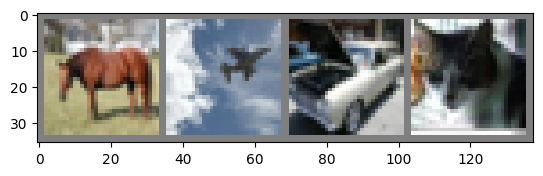

Horses Airplanes Cars Cats


In [8]:
import torchvision
train_iter = iter(train_loader)
images, labels = next(train_iter)
imshow(torchvision.utils.make_grid(images))
classes = ["Airplanes","Cars","Birds","Cats","Deer","Dogs","Frogs","Horses","Ships","Trucks"]
print(', '.join((classes[i] for i in labels)))

## Завдання 3
- Побудуйте просту мережу на основі архітектури LeNet і навчіть її 5 епох.
- Порівняйте точність з архітектурою ResNet18 (переднавчена).
- Використовуйте transfer learning: заморозьте ваги базових шарів.

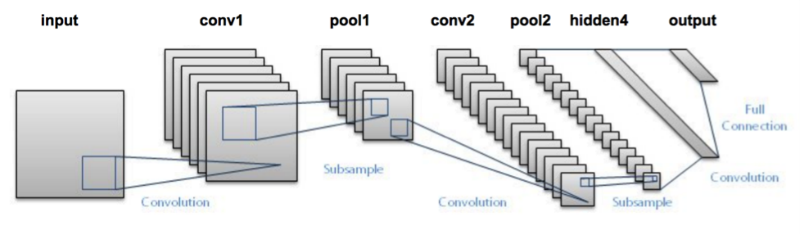

In [16]:
# Побудуйте просту мережу на основі архітектури LeNet
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, classes_count=10):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, classes_count)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(-1, 16 * 5 * 5)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

lenet5 = LeNet5()
print(lenet5)

LeNet5(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)


In [27]:
loss_f = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lenet5.parameters(), lr=0.001)
epochs = 5
losses = []
for epoch in range(epochs) :
    total_loss = 0.0  # загальні втрати за епоху
    for images,labels in train_loader:
        optimizer.zero_grad()
        output = lenet5(images)
        loss = loss_f(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f"Epoch: {epoch+1}, Loss: {total_loss}")

Epoch: 1, Loss: 12971.68811461702
Epoch: 2, Loss: 12575.453409095411
Epoch: 3, Loss: 12296.998568479903
Epoch: 4, Loss: 12010.875497464905
Epoch: 5, Loss: 11789.171308137127


In [28]:
correct = 0
total = 0
mis = []
with torch.no_grad():
    for images, labels in test_loader :
        output = lenet5(images)
        _, predicted = torch.max(output, 1)
        total += len(labels)
        correct += (predicted == labels).sum().item()

        for i in range(len(labels)) :
            if predicted[i] != labels[i] :
                mis.append({
                    "label": labels[i],
                    "predicted": predicted[i],
                    "image": images[i]
                })
print(len(mis))

3881


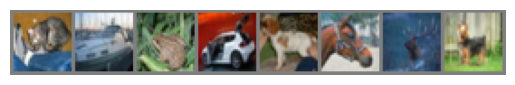

In [29]:
imshow(torchvision.utils.make_grid([mis[i]["image"] for i in range(8) ]))

In [30]:
print(', '.join((f"{classes[mis[i]["label"]]}/{classes[mis[i]["predicted"]]}" for i in range(8))))

Cats/Ships, Ships/Trucks, Frogs/Deer, Cars/Cats, Dogs/Cats, Horses/Dogs, Deer/Airplanes, Dogs/Deer


In [ ]:
# Порівняйте точність з архітектурою ResNet18 (переднавчена).
resnet18 = torchvision.models.resnet18(weights="DEFAULT")

# Використовуйте transfer learning: заморозьте ваги базових шарів.
for param in resnet18.parameters():
    param.requires_grad = False

# замінюємо останній шар моделі на новий з виходом на 10 класів
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 10)

# transfer learning - комбінація попереднього навчання та донавчання (останніх шарів)
# звернути увагу: до оптимізатора передаємо тільки параметри fc-шару
optimizer = torch.optim.Adam(resnet18.fc.parameters(), lr=0.001)
epochs = 5
losses = []
for epoch in range(epochs) :
    total_loss = 0.0  # загальні втрати за епоху
    for images,labels in train_loader:
        optimizer.zero_grad()
        output = resnet18(images)
        loss = loss_f(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f"Epoch: {epoch+1}, Loss: {total_loss}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\samoylenko_d/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Epoch: 1, Loss: 26384.715287655592


In [ ]:
# зберігаємо результати навчання для можливості подальшого використання
torch.save(lenet5.state_dict(), 'lenet5.pth')
torch.save(resnet18.state_dict(), 'resnet18.pth')